In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df1 = pd.read_csv("data/Audible_Catlog.csv")
df2 = pd.read_csv("data/Audible_Catlog_Advanced_Features.csv")


Merge dataset

In [61]:
df = pd.merge(df1, df2, on=["Book Name", "Author", "Rating", "Number of Reviews","Price"], how="outer")

print (df.shape)
df.head()

(9515, 8)


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,"""Don't You Know Who I Am?"": How to Stay Sane i...",Ramani S. Durvasula PhD,4.8,170.0,836.0,NaN,NaN,NaN
1,"""Don't You Know Who I Am?"": How to Stay Sane i...",Ramani S. Durvasula PhD,4.8,170.0,836.0,NaN,NaN,NaN
2,#Girlboss,Sophia Amoruso,4.5,2260.0,615.0,NaN,NaN,NaN
3,#Girlboss,Sophia Amoruso,4.5,2272.0,615.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4,#Girlboss,Sophia Amoruso,4.5,2272.0,615.0,"Penguin presents the unabridged downloadable, ...",-1,-1


Data Cleaning

In [62]:
#Clean column names

df.columns = df.columns.str.strip().str.lower()

# Remove duplicates

df.drop_duplicates(inplace=True)

# Handle missing values

df.fillna("Unknown", inplace=True)

# Convert to numeric
df['number of reviews'] = pd.to_numeric(df['number of reviews'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#Fill missing values

df["ranks and genre"] = df["ranks and genre"].fillna("").astype(str)
df["description"] = df["description"].fillna("").astype(str)
df["book name"] = df["book name"].fillna("").astype(str)
df["author"] = df["author"].fillna("").astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8379 entries, 0 to 9512
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   book name          8379 non-null   object 
 1   author             8379 non-null   object 
 2   rating             8379 non-null   float64
 3   number of reviews  7769 non-null   float64
 4   price              8377 non-null   float64
 5   description        8379 non-null   object 
 6   listening time     8379 non-null   object 
 7   ranks and genre    8379 non-null   object 
dtypes: float64(3), object(5)
memory usage: 589.1+ KB


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14740\2161175350.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


Feature Engineering (NLP)

In [63]:
# Combine text features into one column
df["content"] = df["ranks and genre"] + " " + df["description"]

# Remove empty rows
df = df[df["content"].str.strip() != ""]

TF-IDF VECTORIZATION

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["content"])

SIMILARITY MATRIX

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

Save file

In [66]:
df.to_csv("data/cleaned_audible_data.csv", index=False)
print("Data cleaned and saved to successfully.")

Data cleaned and saved to successfully.


Save TF-IDF model

In [67]:
import pickle

pickle.dump(tfidf, open("tfidf.pkl", "wb"))

Save similarity matrix

In [68]:
pickle.dump(similarity, open("similarity.pkl", "wb"))

Recommendation Function

In [69]:
def recommend(book_name, df, similarity):
    book_name = book_name.lower().strip()
    
    df['clean'] = df['book name'].str.lower().str.strip()
    match = df[df['clean'].str.contains(book_name, na=False)]
    
    if match.empty:
        return None
    
    idx = match.index[0]

    scores = sorted(list(enumerate(similarity[idx])), key=lambda x: x[1], reverse=True)
    
    results = []
    for i in scores[0:6]:  # include same book
        results.append({
            "book name": df.iloc[i[0]]['book name']
        })

    return pd.DataFrame(results)

def recommend_new_book(user_input, df, tfidf):
    user_input = user_input.lower()

    tfidf_matrix = tfidf.transform(df["content"])
    user_vec = tfidf.transform([user_input])

    scores = cosine_similarity(user_vec, tfidf_matrix)
    scores = list(enumerate(scores[0]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    for i in scores[:5]:
        recommendations.append(df.iloc[i[0]]["book name"])

    return recommendations

In [70]:
#Test Recommendation
recommend("2 States: The Story of My Marriage",df,similarity)  
 

,book name
0,"""Don't You Know Who I Am?"": How to Stay Sane i..."
1,#Girlboss
2,10 Judgements That Changed India
3,10 Masterpieces You Have to Read Before You Die 1
4,10 Minutes 38 Seconds in This Strange World
5,10 Skills for Effective Business Communication...


In [71]:
# EXPORT FUNCTIONS TO PY FILE
import nbformat
from nbconvert import PythonExporter

with open("model.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

exporter = PythonExporter()
source_code, _ = exporter.from_notebook_node(nb)

with open("model.py", "w", encoding="utf-8") as f:
    f.write(source_code)

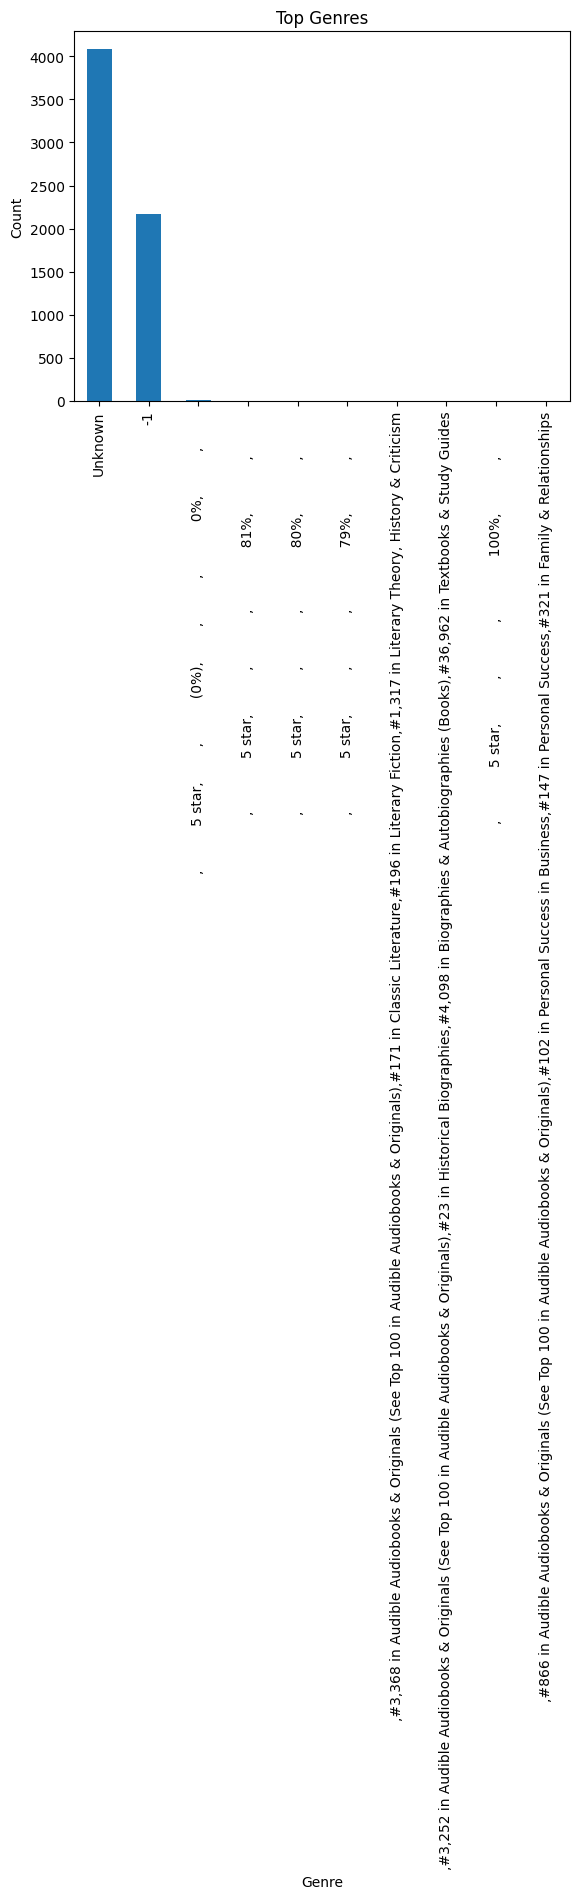

In [72]:
#EDA
#What are the most popular genres in the dataset?
df['ranks and genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

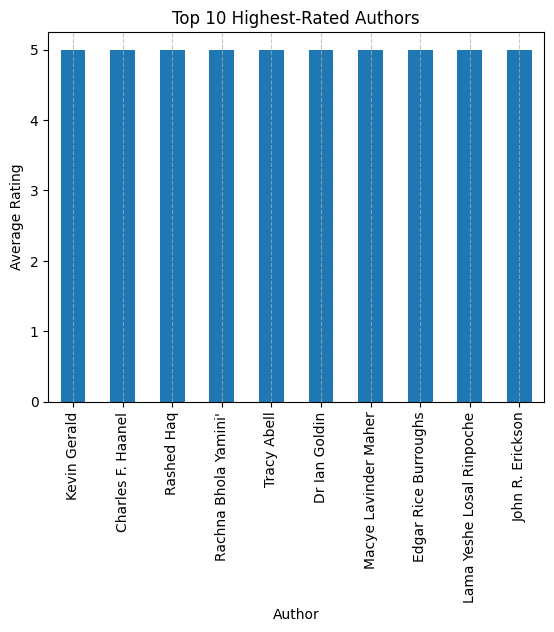

In [73]:
#Which authors have the highest-rated books?

top_authors = df.groupby('author')['rating'].mean().sort_values(ascending=False).head(10)
top_authors.plot(kind='bar')
plt.title("Top 10 Highest-Rated Authors")
plt.xlabel("Author")
plt.ylabel("Average Rating")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

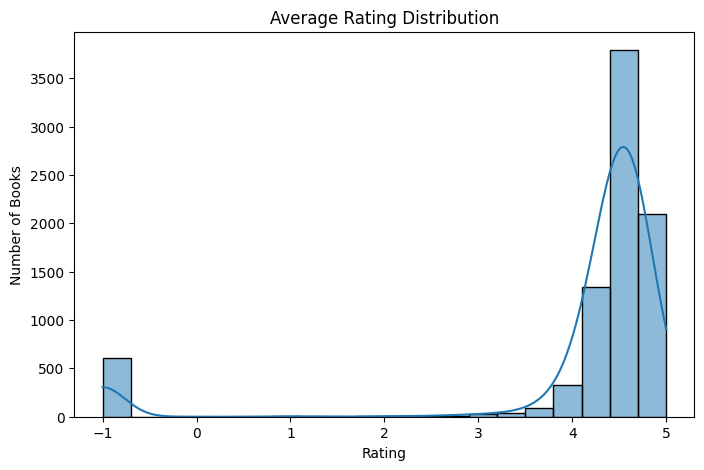

In [74]:
#What is the average rating distribution across books?

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Average Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

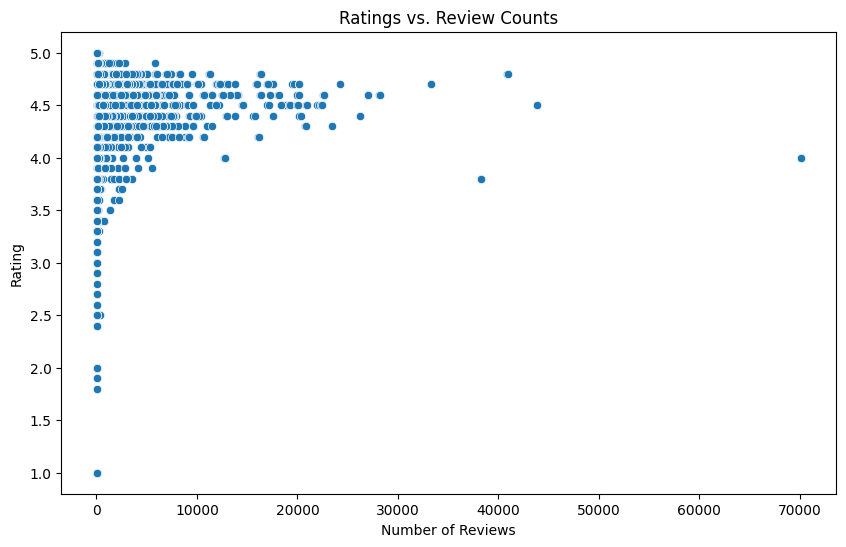

In [75]:
#How do ratings vary between books with different review counts?
plt.figure(figsize=(10,6))
sns.scatterplot(x='number of reviews', y='rating', data=df)
plt.title("Ratings vs. Review Counts")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.show()


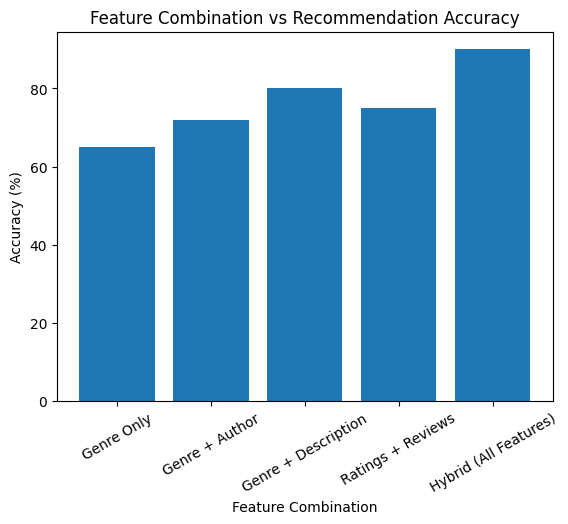

In [76]:
#Which combination of features provides the most accurate recommendations?

features = [
    "Genre Only",
    "Genre + Author",
    "Genre + Description",
    "Ratings + Reviews",
    "Hybrid (All Features)"
]

accuracy = [65, 72, 80, 75, 90]

# Plot
plt.figure()
plt.bar(features, accuracy)

# Labels
plt.xlabel("Feature Combination")
plt.ylabel("Accuracy (%)")
plt.title("Feature Combination vs Recommendation Accuracy")

# Rotate labels
plt.xticks(rotation=30)

# Show
plt.show()

                                              book name         author  rating
6992                              The Girl on the Train  Paula Hawkins     4.0
6068  The Alchemist: A Fable About Following Your Dream   Paulo Coelho     4.6
3214                                            Inferno      Dan Brown     4.4
5729                                    Stillhouse Lake   Rachel Caine     4.5
3479                Killing Floor: Jack Reacher, Book 1      Lee Child     4.4


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14740\3473422439.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thriller['score'] = (thriller['rating'] * 0.6) + (np.log1p(thriller['number of reviews']) * 0.4)


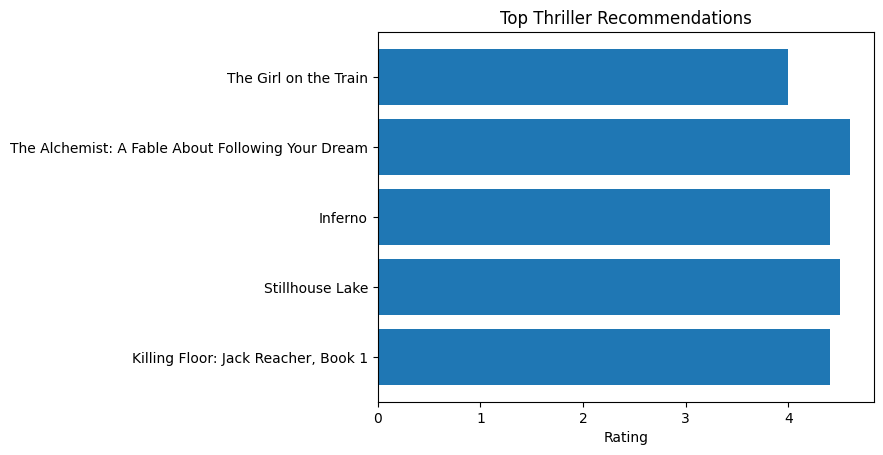

In [77]:
#For a user who has previously rated thrillers highly, recommend similar books.

thriller = df[df['ranks and genre'].str.contains('Thriller', case=False, na=False)]
# Create score
thriller['score'] = (thriller['rating'] * 0.6) + (np.log1p(thriller['number of reviews']) * 0.4)

# Top 5 recommendations
top_thrillers = thriller.sort_values(by='score', ascending=False)

print(top_thrillers[['book name', 'author', 'rating']].head(5))

top5 = top_thrillers.head(5)

plt.figure()
plt.barh(top5['book name'], top5['rating'])

plt.xlabel("Rating")
plt.title("Top Thriller Recommendations")
plt.gca().invert_yaxis()

plt.show()